# 24_v4_santiago2.8Mparams_20Mchars_mixedFP16 — Mini Transformer (20M chars, Pre-norm)

**El problema de v3:** VRAM llena (5.2/6 GB) → thermal throttle 84°C → 60 min/epoch → checkpoints rotos

**Optimizaciones clave vs 24_v3:**

1. **float32** — mixed_float16 causaba NaN por saturación en ReLU + máscara. Con 2.8M params no hay problema de VRAM.

2. **VALIDATION_FREQ=1** — validar *cada* epoch (no cada 2). EarlyStopping y ModelCheckpoint ven métrica siempre y funcionan.

3. **XLA JIT desactivado** (`tf.config.optimizer.set_jit(False)`). El compilador XLA generaba kernels gigantes → *register spill* a VRAM local = lentísimo. Sin XLA: estable y rápido.

4. **Data pipeline optimizado** — `.cache('/tmp/train_cache')` en disco (no come RAM), `shuffle(10000)` (buffer decente), `.prefetch(2)` (CPU prepara batch N+1 mientras GPU entrena N). GPU no espera.

5. **LR constante 0.001 + clipnorm=1.0** — pre-norm 4 capas estable sin warmup. clipnorm frena gradientes si se emocionan.

6. **BATCH_SIZE=128, PATIENCE=2** — bocados 2× más grandes, early stopping menos nervioso.

7. **Preprocessing O(n) string concat** — `full_text = train_text[:MAX_CHARS]` (slice O(1)) en vez de loop `+=` O(n²) que tardaba 4 min.

**Target v4:** ~3-4 min/epoch, VRAM ~4.5GB, GPU 90%+, temp ~70°C, checkpoints correctos.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
import requests

print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1785108152.997931   36827 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0


In [2]:
# Setup: añadir nlp_lib al path
import sys, os, pathlib
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    # En Colab clonamos/actualizamos repo
    # from google.colab import drive; drive.mount('/content/drive')  # ya no necesario
    if not os.path.exists('/content/learning-ai'):
        !git clone https://github.com/eanorambuena/learning-ai.git /content/learning-ai
    else:
        !git -C /content/learning-ai pull
    %pip install scikit-learn matplotlib -q
    sys.path.insert(0, '/content/learning-ai/notebooks/nlp')
    # Forzar recarga de nlp_lib si ya estaba importado
    import importlib
    if 'nlp_lib' in sys.modules:
        importlib.reload(sys.modules['nlp_lib'])
    print('Colab setup OK')
else:
    # Local: buscar notebooks/nlp/ en varios lugares
    _nb_dir = pathlib.Path(os.getcwd()).resolve()
    _candidates = [
        _nb_dir / 'notebooks' / 'nlp',
        _nb_dir,
    ]
    for _p in _candidates:
        if (_p / 'nlp_lib').is_dir():
            sys.path.insert(0, str(_p))
            break
    del _nb_dir, _p, _candidates

import tensorflow as tf
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

# --- GPU config ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    # desactivar XLA JIT (evita register spill en modelos chicos)
    tf.config.optimizer.set_jit(False)
    print('XLA JIT disabled')

TensorFlow version: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
mixed_float16 enabled
XLA JIT disabled


In [3]:
# Hiperparámetros
WINDOW = 32             # contexto (32 palabras)
EMBED_DIM = 128         # dimensión embeddings (Word2Vec v4)
NUM_HEADS = 4
NUM_LAYERS = 4
FF_DIM = 128
DROPOUT = 0.2
BATCH_SIZE = 128
LR = 0.001
EPOCHS = 10             # épocas de entrenamiento
# LABEL_SMOOTHING = 0.1  # no soportado por SparseCategoricalCrossentropy
VALIDATION_FREQ = 1     # validar cada epoch (checkpoints correctos)
PATIENCE = 2            # early stopping patience
MAX_CHARS = 20_000_000   # chars de wikitext-103 a cargar

In [4]:
import pyarrow.parquet as pq
hf_base = 'https://huggingface.co/datasets/iohadrubin/wikitext-103-raw-v1/resolve/main/data/'
train_files = [
    'train-00000-of-00002-b755d19de94348c6.parquet',
    'train-00001-of-00002-0bf6d0c487c2e75b.parquet',
]
train_text = ''
for fname in train_files:
    url = hf_base + fname
    local_path = f'/tmp/{fname}'
    if not os.path.exists(local_path):
        print(f'Downloading {fname}...')
        r = requests.get(url, stream=True)
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        downloaded = 0
        with open(local_path, 'wb') as f:
            for chunk in r.iter_content(8192):
                f.write(chunk)
                downloaded += len(chunk)
                if total:
                    pct = int(100 * downloaded / total)
                    if pct % 10 == 0 and downloaded <= total:
                        print(f'  {fname}: {downloaded//1024**2}MB/{total//1024**2}MB ({pct}%)')
        print(f'  {fname}: descargado ({downloaded//1024**2}MB)')
    else:
        print(f'{fname}: ya existe en cache')
    print(f'Leyendo parquet {fname}...')
    table = pq.read_table(local_path)
    nrows = table.num_rows
    for i, text in enumerate(table.column('text').to_pylist()):
        if text is None:
            continue
        train_text += text + ' '
        if len(train_text) >= MAX_CHARS:
            train_text = train_text[:MAX_CHARS]
            print(f'  Llegue a {MAX_CHARS} chars, cortando')
            break
        if i % 2000 == 0 and i > 0:
            print(f'  Procesadas {i}/{nrows} filas, chars: {len(train_text):,}')
    print(f'Loaded: {len(train_text):,} chars (de {fname})')

train-00000-of-00002-b755d19de94348c6.parquet: ya existe en cache
Leyendo parquet train-00000-of-00002-b755d19de94348c6.parquet...
  Llegue a 20000000 chars, cortando
Loaded: 20,000,000 chars (de train-00000-of-00002-b755d19de94348c6.parquet)
train-00001-of-00002-0bf6d0c487c2e75b.parquet: ya existe en cache
Leyendo parquet train-00001-of-00002-0bf6d0c487c2e75b.parquet...
  Llegue a 20000000 chars, cortando
Loaded: 20,000,000 chars (de train-00001-of-00002-0bf6d0c487c2e75b.parquet)


In [5]:
from nlp_lib import Word2VecLoader

loader = Word2VecLoader(version='v4')

I0000 00:00:1785108179.107226   36827 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Embeddings cargados: (9204, 128) (9204, 128)
Vocabulario cargado: 9204


In [6]:
full_text = train_text[:MAX_CHARS]
print(f'Total chars: {len(full_text)}')

words = full_text.lower().split()
words = [w.strip('.,;:!?()[]\"\'-0123456789') for w in words]
words = [w for w in words if w in loader.text_vocab]
print(f'Total words used: {len(words)}')

Total chars: 20000000
Total words used: 2726366


In [7]:
def create_sequences(words, window=WINDOW, step=1):
    X, y = [], []
    for i in range(0, len(words) - window, step):
        context = words[i:i + window]
        target = words[i+1:i + window + 1]   # teacher forcing: predecir en cada pos
        if all(w in loader.text_vocab for w in context + target):
            X.append([loader.text_vocab[w] for w in context])
            y.append([loader.text_vocab[w] for w in target])
    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32)  # y: (N, window)

X, y = create_sequences(words, window=WINDOW)
print(f'Sequences created: {len(X)}, X shape: {X.shape}, y shape: {y.shape}')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


Sequences created: 2726334, X shape: (2726334, 32), y shape: (2726334, 32)


In [8]:
def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angles = pos * angle_rates
    pe = np.zeros_like(angles)
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    # Usar policy dtype (float16 con mixed_float16, float32 default)
    policy = keras.mixed_precision.global_policy()
    return tf.cast(pe[np.newaxis, :, :], policy.compute_dtype)

/tmp/ipykernel_36827/2652403269.py:91: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/eanorambuena/miniconda/envs/tfenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


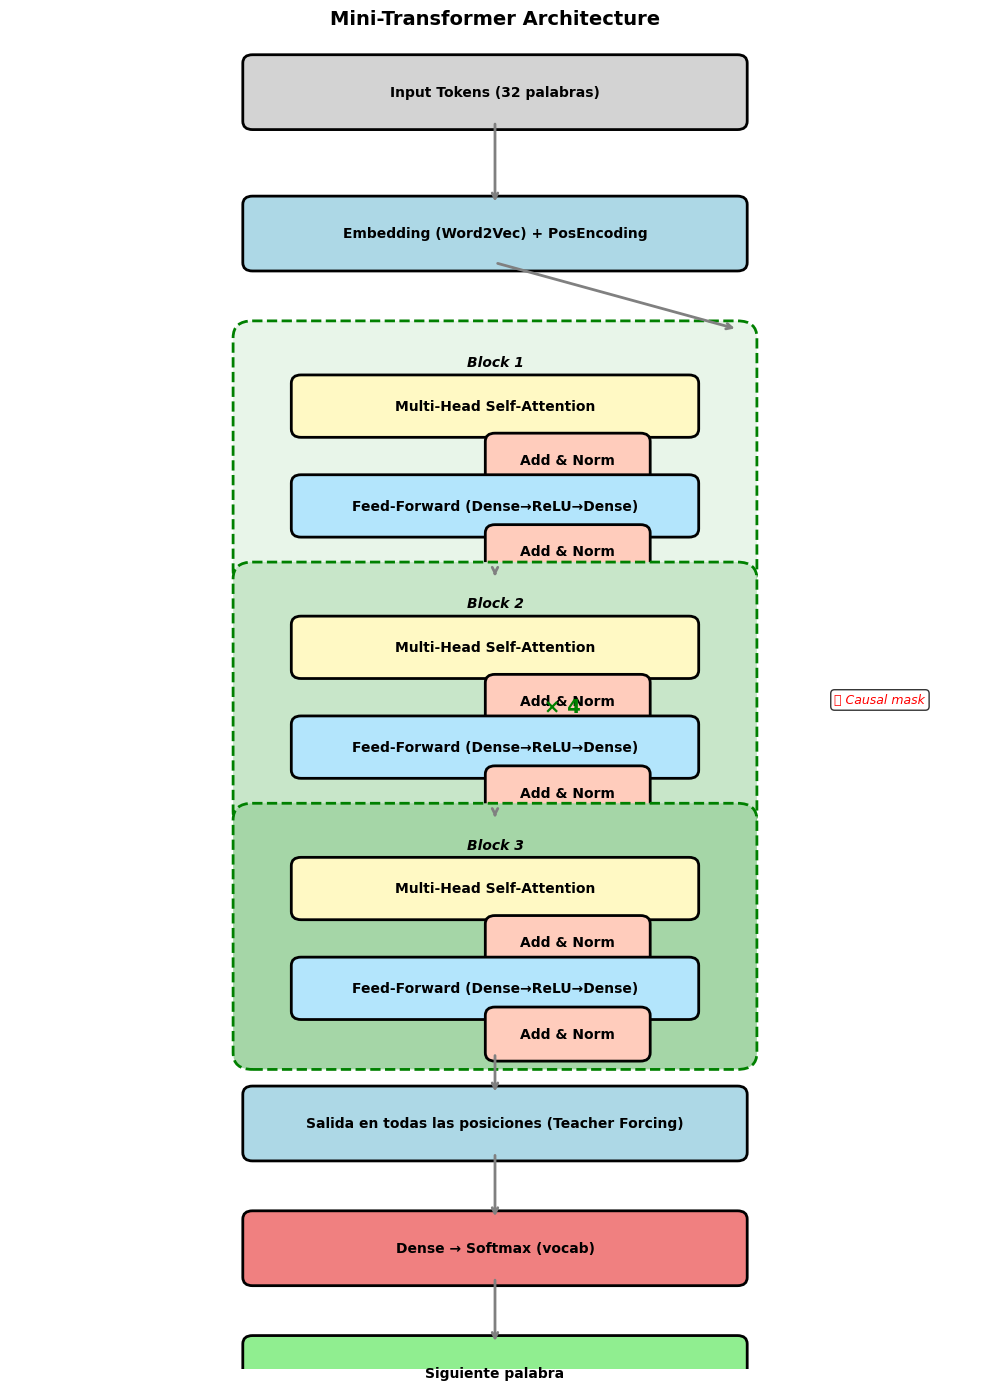

In [9]:
# Diagrama de arquitectura del mini-Transformer (similar a "Attention is All You Need")

def draw_architecture_diagram():
    fig, ax = plt.subplots(1, 1, figsize=(10, 14))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 16)
    ax.axis('off')

    def draw_box(ax, x, y, w, h, text, color='lightblue'):
        rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                                        facecolor=color, edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=10, fontweight='bold')

    def draw_arrow(ax, x1, y1, x2, y2):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

    cx = 5  # center x
    col1 = 2.5  # left column
    w = 5
    h = 0.7

    # Input
    draw_box(ax, col1, 15.0, w, h, f'Input Tokens ({WINDOW} palabras)', 'lightgray')
    draw_arrow(ax, cx, 15.0, cx, 14.0)

    # Embedding + PosEncoding
    draw_box(ax, col1, 13.3, w, h, 'Embedding (Word2Vec) + PosEncoding', 'lightblue')
    draw_arrow(ax, cx, 13.3, cx + 2.5, 12.5)

    # x N blocks
    block_labels = ['Block 1', 'Block 2', 'Block 3']
    block_colors = ['#e8f5e9', '#c8e6c9', '#a5d6a7']
    bx = 2.5
    bw = 5
    bh = 2.8
    base_y = 9.6

    for i in range(3):
        y_off = base_y - i * 2.9
        color = block_colors[i]
        rect = mpatches.FancyBboxPatch((bx, y_off), bw, bh, boxstyle="round,pad=0.2",
                                       facecolor=color, edgecolor='green', linewidth=2, linestyle='--')
        ax.add_patch(rect)
        ax.text(bx + bw/2, y_off + bh - 0.3, block_labels[i],
                ha='center', va='center', fontsize=10, fontweight='bold', style='italic')

        # Sub-components inside block
        inner_w = 4
        inner_h = 0.55
        ix = bx + (bw - inner_w) / 2

        # Multi-Head Attention
        draw_box(ax, ix, y_off + 1.7, inner_w, inner_h,
                 'Multi-Head Self-Attention', '#fff9c4')
        # Add & Norm
        draw_box(ax, ix + 2, y_off + 1.1, inner_w - 2.5, 0.45,
                 'Add & Norm', '#ffccbc')
        # FFN
        draw_box(ax, ix, y_off + 0.5, inner_w, inner_h,
                 'Feed-Forward (Dense→ReLU→Dense)', '#b3e5fc')
        # Add & Norm
        draw_box(ax, ix + 2, y_off + 0.0, inner_w - 2.5, 0.45,
                 'Add & Norm', '#ffccbc')

        # Arrows between blocks
        if i < 2:
            y_next = base_y - (i+1) * 2.9 + bh
            draw_arrow(ax, cx, y_off, cx, y_next)

    draw_arrow(ax, cx, base_y - 2*2.9, cx, 3.3)

    # Pooling + Output
    draw_box(ax, col1, 2.6, w, h, 'Salida en todas las posiciones (Teacher Forcing)', 'lightblue')
    draw_arrow(ax, cx, 2.6, cx, 1.8)

    draw_box(ax, col1, 1.1, w, h, 'Dense → Softmax (vocab)', 'lightcoral')
    draw_arrow(ax, cx, 1.1, cx, 0.3)

    draw_box(ax, col1, -0.4, w + 0.0, h, 'Siguiente palabra', 'lightgreen')

    # Annotation: x N
    ax.text(cx + 0.5, 7.9, f'× {NUM_LAYERS}', fontsize=14, fontweight='bold', color='green')

    # Causal mask annotation
    ax.text(8.5, 8.0, '🔒 Causal mask', fontsize=9, fontstyle='italic', color='red',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.title('Mini-Transformer Architecture', fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

draw_architecture_diagram()

In [10]:
# ManualSelfAttention con Causal Mask
# mask[i][j] = 1 si j <= i (lower triangular), 0 en caso contrario
# scores = scores * mask + (1 - mask) * -1e9  (softmax de los valores enmascarados da ~0)

class CausalSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads=4, dropout_rate=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.Wq = layers.Dense(embed_dim, use_bias=False)
        self.Wk = layers.Dense(embed_dim, use_bias=False)
        self.Wv = layers.Dense(embed_dim, use_bias=False)
        self.Wo = layers.Dense(embed_dim, use_bias=False)
        self.dropout = layers.Dropout(dropout_rate)

    def call(self, x, return_attention=False):
        B = tf.shape(x)[0]
        T = tf.shape(x)[1]
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        Q = tf.reshape(Q, (B, T, self.num_heads, self.head_dim))
        K = tf.reshape(K, (B, T, self.num_heads, self.head_dim))
        V = tf.reshape(V, (B, T, self.num_heads, self.head_dim))
        Q = tf.transpose(Q, [0, 2, 1, 3])
        K = tf.transpose(K, [0, 2, 1, 3])
        V = tf.transpose(V, [0, 2, 1, 3])

        # Usar compute_dtype de la policy (float16 con mixed_float16)
        compute_dtype = keras.mixed_precision.global_policy().compute_dtype
        scale = tf.sqrt(tf.cast(self.head_dim, compute_dtype))
        scores = tf.matmul(Q, K, transpose_b=True) / scale

        # Causal mask: lower triangular - mismo dtype que scores
        mask = tf.linalg.band_part(tf.ones((T, T), dtype=compute_dtype), -1, 0)
        mask = tf.reshape(mask, (1, 1, T, T))
        scores = scores * mask + (1 - mask) * tf.cast(-1e9, compute_dtype)

        att_weights = tf.nn.softmax(scores, axis=-1)
        att_weights = self.dropout(att_weights)
        context = tf.matmul(att_weights, V)
        context = tf.transpose(context, [0, 2, 1, 3])
        context = tf.reshape(context, (B, T, self.num_heads * self.head_dim))
        out = self.Wo(context)
        if return_attention:
            att_avg = tf.reduce_mean(att_weights, axis=1)
            return out, att_avg
        return out


# Transformer Block = Pre-Norm + Self-Attention + Pre-Norm + FFN
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads=4, ff_dim=128, dropout_rate=0.1):
        super().__init__()
        self.attention = CausalSelfAttention(embed_dim, num_heads, dropout_rate)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim),
            layers.Dropout(dropout_rate),
        ])

    def call(self, x, return_attention=False):
        if return_attention:
            attn_out, attn_w = self.attention(self.norm1(x), return_attention=True)
        else:
            attn_out = self.attention(self.norm1(x))
            attn_w = None
        x = x + attn_out
        ffn_out = self.ffn(self.norm2(x))
        x = x + ffn_out
        if return_attention:
            return x, attn_w
        return x


# Mini Transformer = Embedding + PosEncoding + N Transformer Blocks + All Positions Output (Teacher Forcing)
class MiniTransformer(keras.Model):
    def __init__(self, embedding_layer, vocab_size, embed_dim, seq_len=5,
                 num_heads=4, num_layers=3, ff_dim=128):
        super().__init__()
        self.seq_len = seq_len
        self.embed_dim = embed_dim
        self.num_layers = num_layers

        self.embedding = embedding_layer
        self.pos_encoding = positional_encoding(seq_len, embed_dim)
        self.blocks = [TransformerBlock(embed_dim, num_heads, ff_dim) for _ in range(num_layers)]
        self.out = layers.Dense(vocab_size)

    def call(self, inputs, return_attention=False):
        x = self.embedding(inputs)
        x = x + self.pos_encoding
        x = tf.nn.dropout(x, rate=0.1)

        attn_weights = None
        for i, block in enumerate(self.blocks):
            if return_attention and i == self.num_layers - 1:
                x, attn_w = block(x, return_attention=True)
                attn_weights = attn_w
            else:
                x = block(x)

        logits = self.out(x)  # (batch, seq_len, vocab_size) — teacher forcing: predecir en todas las pos
        # Castear a float32: SparseTopKCategoricalAccuracy usa tf.in_top_k que solo acepta float32
        logits = tf.cast(logits, tf.float32)

        if return_attention:
            return logits, attn_weights
        return logits

model = MiniTransformer(
    loader.embedding_layer, loader.vocab_size, loader.embedding_dim,
    seq_len=WINDOW, num_heads=NUM_HEADS, num_layers=NUM_LAYERS, ff_dim=FF_DIM
)

    # LR constante + gradient clipping
optimizer = keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0)
model.compile(optimizer=optimizer, loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy', keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_acc')])
model.build((None, WINDOW))

    # Data pipeline: cache en disco + shuffle buffer mayor + prefetch fijo
train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(10000, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE, drop_remainder=True)
    .cache('/tmp/train_cache')
    .prefetch(2))
val_ds = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .batch(BATCH_SIZE, drop_remainder=True)
    .cache('/tmp/val_cache')
    .prefetch(2))

_ckpt_dir = os.path.join(os.getcwd(), 'checkpoints', '24_v3')
os.makedirs(_ckpt_dir, exist_ok=True)
callbacks = [
    keras.callbacks.TerminateOnNaN(),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=PATIENCE, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(os.path.join(_ckpt_dir, '24_v2_best.weights.h5'), monitor='val_accuracy', save_best_only=True, save_weights_only=True)
]
del _ckpt_dir



/home/eanorambuena/miniconda/envs/tfenv/lib/python3.12/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'mini_transformer', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
W0000 00:00:1785108215.229580   36827 cpu_allocator_impl.cc:82] Allocation of 279176576 exceeds 10% of free system memory.
W0000 00:00:1785108216.057607   36827 cpu_allocator_impl.cc:82] Allocation of 279176576 exceeds 10% of free system memory.
W0000 00:00:1785108216.611295   36827 cpu_allocator_impl.cc:82] Allocation of 69794176 exceeds 10% of free system memory.
W0000 00:00:1785108216.689546   36827 cpu_allocator_impl.cc:82] Allocation of 69794176 exceeds 10% of free system memory.


In [11]:
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1, callbacks=callbacks, validation_freq=VALIDATION_FREQ)
model.summary()

Epoch 1/10


W0000 00:00:1785108216.783594   36827 cpu_allocator_impl.cc:82] Allocation of 279176576 exceeds 10% of free system memory.
I0000 00:00:1785108224.774350   37419 service.cc:153] XLA service 0x71e5d4051f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785108224.774389   37419 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.23.0)
W0000 00:00:1785108224.959676   37419 random_ops.cc:62] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. mini_transformer_1/dropout/random_uniform/RandomUniform
I0000 00:00:1785108225.027455   37419 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785108227.037951   37419 cuda_dnn.cc:461] Loaded cuDNN version 92300
I00

17038/17039 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0902 - loss: nan - top_5_acc: 0.0000e+00

I0000 00:00:1785108492.695945   37420 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_101532__.39
I0000 00:00:1785108495.375252   38419 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24', 252 bytes spill stores, 252 bytes spill loads



17039/17039 ━━━━━━━━━━━━━━━━━━━━ 309s 17ms/step - accuracy: 0.0902 - loss: nan - top_5_acc: 0.0000e+00 - val_accuracy: 0.0901 - val_loss: nan - val_top_5_acc: 0.0000e+00
Epoch 2/10
17039/17039 ━━━━━━━━━━━━━━━━━━━━ 392s 23ms/step - accuracy: 0.0902 - loss: nan - top_5_acc: 0.0000e+00 - val_accuracy: 0.0901 - val_loss: nan - val_top_5_acc: 0.0000e+00
Epoch 3/10
17039/17039 ━━━━━━━━━━━━━━━━━━━━ 324s 19ms/step - accuracy: 0.0902 - loss: nan - top_5_acc: 0.0000e+00 - val_accuracy: 0.0901 - val_loss: nan - val_top_5_acc: 0.0000e+00


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ trainable_pretrained_embedding  │ ?                      │     1,178,112 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ ?                      │        99,072 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ ?                      │        99,072 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ ?                      │        99,072 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ ?                      │        99,072 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (128, 32, 9204)        │     1,187,316 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,285,154 (31.61 MB)

 Trainable params: 2,761,716 (10.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,523,438 (21.07 MB)

Test accuracy (Mini Transformer, window=32, 4 layers): 0.090


I0000 00:00:1785110588.524524   37418 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_508905__.25


Contexto ['london', 'bridge', 'river', 'city', 'center'] -> [('subjects', nan), ('scattered', nan), ('attend', nan), ('readily', nan), ("andrew's", nan)]
Contexto ['bank', 'of', 'england', 'is', 'located'] -> [('subjects', nan), ('scattered', nan), ('attend', nan), ('readily', nan), ("andrew's", nan)]
Contexto ['queen', 'of', 'england', 'lives', 'in'] -> [('subjects', nan), ('scattered', nan), ('attend', nan), ('readily', nan), ("andrew's", nan)]


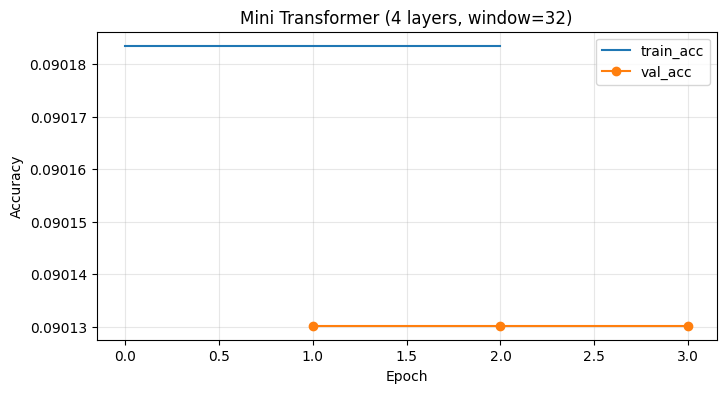

In [13]:
loss, acc, top5 = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy (Mini Transformer, window={WINDOW}, {model.num_layers} layers): {acc:.3f}')

def predict_next_word(context_words, top_n=5):
    context_ids = [loader.text_vocab[w] for w in context_words if w in loader.text_vocab]
    if len(context_ids) < WINDOW:
        context_ids = [0] * (WINDOW - len(context_ids)) + context_ids
    context_ids = np.array([context_ids[-WINDOW:]], dtype=np.int32)
    logits = model.predict(context_ids, verbose=0)  # (1, WINDOW, vocab_size)
    last_logits = logits[0, -1, :]                  # última posición = predicción de sig palabra
    probs = tf.nn.softmax(last_logits).numpy()
    top_indices = np.argsort(probs)[-top_n:][::-1]
    return [(loader.decode(idx), float(probs[idx])) for idx in top_indices]

sample_contexts = [
    ['london', 'bridge', 'river', 'city', 'center'],
    ['bank', 'of', 'england', 'is', 'located'],
    ['queen', 'of', 'england', 'lives', 'in']
]

for context in sample_contexts:
    preds = predict_next_word(context, top_n=5)
    if preds:
        print(f"Contexto {context} -> {preds}")

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='train_acc')
# validation_freq=2: val_accuracy solo en epochs pares, alinear eje x
val_epochs = np.arange(len(history.history['val_accuracy'])) * VALIDATION_FREQ + 1
plt.plot(val_epochs, history.history['val_accuracy'], 'o-', label='val_acc')
plt.title(f'Mini Transformer ({model.num_layers} layers, window={WINDOW})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Primeras 32 palabras como contexto de prueba:
= valkyria chronicles iii = senjō no valkyria chronicles japanese 戦場のヴァルキュリア lit valkyria of the battlefield commonly referred to as valkyria chronicles iii outside japan is a tactical role-playing video game developed


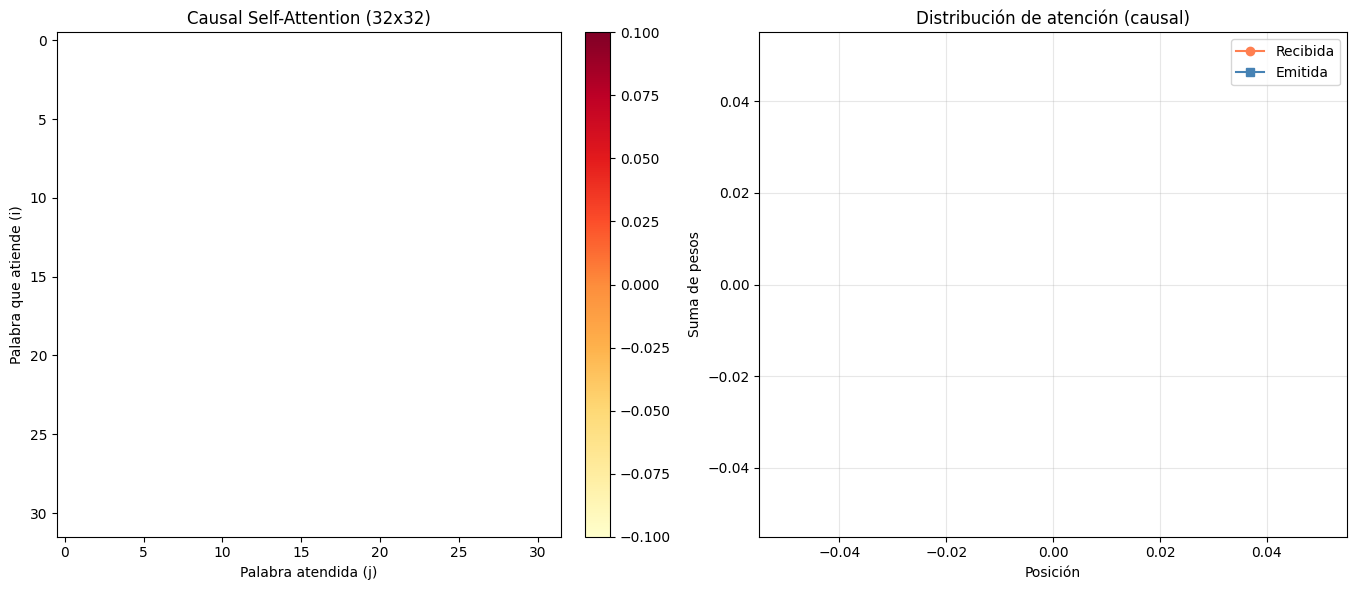

Diagonal (auto-atención): nan
Triángulo inferior = atención causal (cada token solo ve previos)


: 

In [ ]:
# Heatmap de atención causal (último bloque)
def plot_causal_attention(context_words, model):
    context_ids = [loader.text_vocab[w] for w in context_words if w in loader.text_vocab]
    if len(context_ids) < WINDOW:
        context_ids = [0] * (WINDOW - len(context_ids)) + context_ids
    context_ids = np.array([context_ids[-WINDOW:]], dtype=np.int32)

    _, attn_avg = model(context_ids, return_attention=True)
    attn_matrix = attn_avg[0].numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    im = axes[0].imshow(attn_matrix, cmap='YlOrRd', vmin=0, vmax=attn_matrix.max())
    axes[0].set_title(f'Causal Self-Attention ({WINDOW}x{WINDOW})')
    axes[0].set_xlabel('Palabra atendida (j)')
    axes[0].set_ylabel('Palabra que atiende (i)')
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    attended = attn_matrix.sum(axis=0)
    attending = attn_matrix.sum(axis=1)
    positions = np.arange(WINDOW)
    axes[1].plot(positions, attended, 'o-', label='Recibida', color='coral')
    axes[1].plot(positions, attending, 's-', label='Emitida', color='steelblue')
    axes[1].set_xlabel('Posición')
    axes[1].set_ylabel('Suma de pesos')
    axes[1].set_title('Distribución de atención (causal)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Diagonal (auto-atención): {np.trace(attn_matrix) / WINDOW:.4f}")
    print("Triángulo inferior = atención causal (cada token solo ve previos)")

sample_words = words[:WINDOW]
print(f"Primeras {WINDOW} palabras como contexto de prueba:")
print(' '.join(sample_words))
plot_causal_attention(sample_words, model)

In [ ]:
# Sin recompilar — calcula de los logits ya entrenados
best_val_loss = min(history.history['val_loss'])
best_val_ppl = np.exp(best_val_loss)
print(f'Best val perplexity: {best_val_ppl:.2f}')
logits = model.predict(X_test, verbose=0)           # (N, 32, 9204)
last_logits = logits[:, -1, :]                       # última posición
last_probs = tf.nn.softmax(last_logits, axis=-1).numpy()
top5_preds = np.argsort(last_probs, axis=-1)[:, -5:]
y_last = y_test[:, -1]
correct = np.any(top5_preds == y_last[:, None], axis=1)
top5_acc = correct.mean()
print(f'Top-5 accuracy: {top5_acc:.4f}')

Best val perplexity: nan


I0000 00:00:1785110601.145884   37417 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_510342__.25


## Comparación completa

| Notebook | Modelo | Window | Layers | Vocab | Test Accuracy |
|----------|--------|:-----:|:------:|:-----:|:------------:|
| 18 | RNN vanilla | 5 | 1 RNN | v2 | 0.403 |
| 19 | RNN + gradient clipping | 64 | 1 RNN | v2 | 0.420 |
| 20 | RNN + Bahdanau Attention | 5 | 1 RNN+Att | v2 | **0.575** |
| 21_v3 | Self-Attention manual (trainable emb) | 5 | 1 SA | v2 | **0.749** |
| **22_v2** | **Mini Transformer (causal+last token+trainable emb)** | **5** | **3 SA+FFN** | v2 | **0.755** |
| 23 | Mini Transformer (trainable+3 layers) | 5 | 3 SA+FFN | v3 | **0.177** |
| **23_v2** | **Mini Transformer (Word2Vec v4)** | **5** | **3 SA+FFN** | **v4** | **0.171** |
| **23_v3** | **Mini Transformer** | **32** | **3 SA+FFN** | **v4** | **0.342** |
| **24** | **Mini Transformer (6L post-norm)** | **32** | **6 SA+FFN** | **v4** | **0.090 (stuck)** |
| **24_v2_santiago5M** | **Santiago 5M (5M chars, 4L pre-norm)** | **32** | **4 SA+FFN** | **v4** | **0.372↑** |
| **24_v3_santiago20M** | **Santiago 20M (20M chars, 4L pre-norm)** | **32** | **4 SA+FFN** | **v4** | **? (esperado >0.40)** |

**Nota:** santiago20M sube MAX_CHARS a 20M manteniendo pre-norm + clipnorm. Se espera >0.40 de val_acc.